In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
col_names = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'attack_type','difficulty_level'
]

df = pd.read_csv("KDDTest+.txt", names=col_names)
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,mscan,11
5,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.00,0.00,0.00,normal,21
6,0,tcp,smtp,SF,1022,387,0,0,0,0,...,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal,21
7,0,tcp,telnet,SF,129,174,0,0,0,0,...,1.00,0.00,0.00,0.00,0.01,0.01,0.02,0.02,guess_passwd,15
8,0,tcp,http,SF,327,467,0,0,0,0,...,1.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,normal,21
9,0,tcp,ftp,SF,26,157,0,0,0,0,...,0.50,0.08,0.02,0.00,0.00,0.00,0.00,0.00,guess_passwd,7


In [3]:
df.shape

(22544, 43)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [5]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,18.017965
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,4.270361
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [6]:
print("Null values:\n", df.isnull().sum())

Null values:
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                

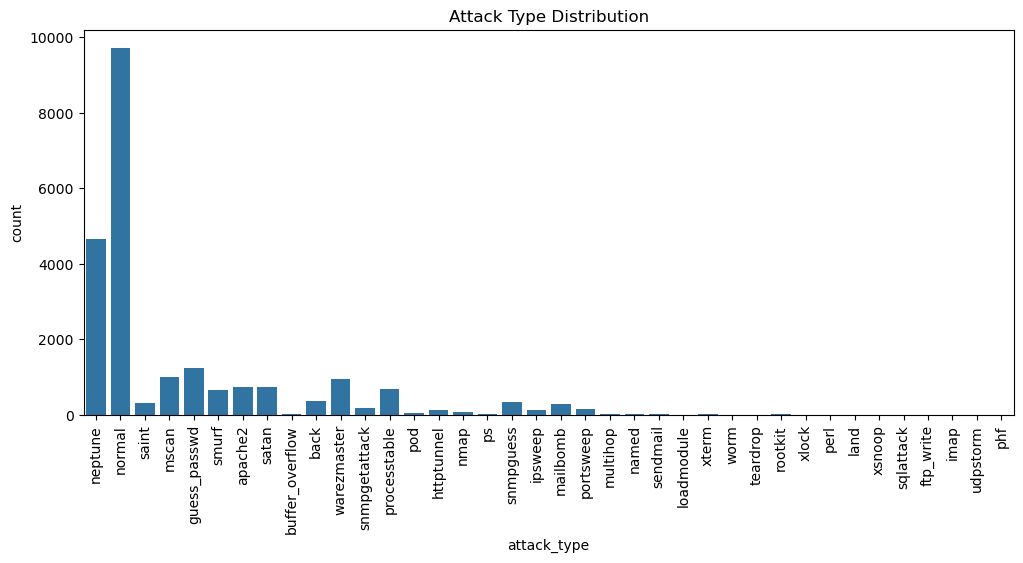

In [7]:
# Attack Type Distribution (Target Balance)
# Shows class imbalance (very important for SVM performance) 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(x='attack_type', data=df)
plt.xticks(rotation=90)
plt.title("Attack Type Distribution")
plt.show()

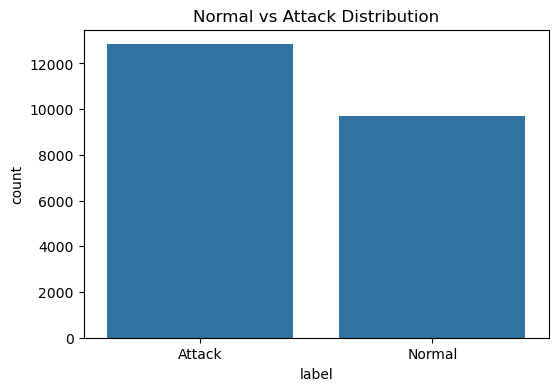

In [8]:
# Binary Classification View (Normal vs Attack)

df['label'] = df['attack_type'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Normal vs Attack Distribution")
plt.show()

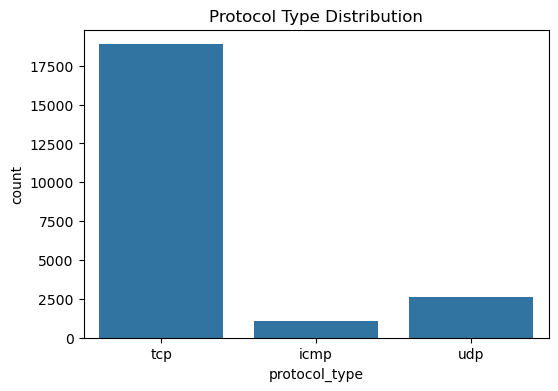

In [9]:
# Protocol Type DistributionHelps 
# SVM understand categorical separation

plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=df)
plt.title("Protocol Type Distribution")
plt.show()

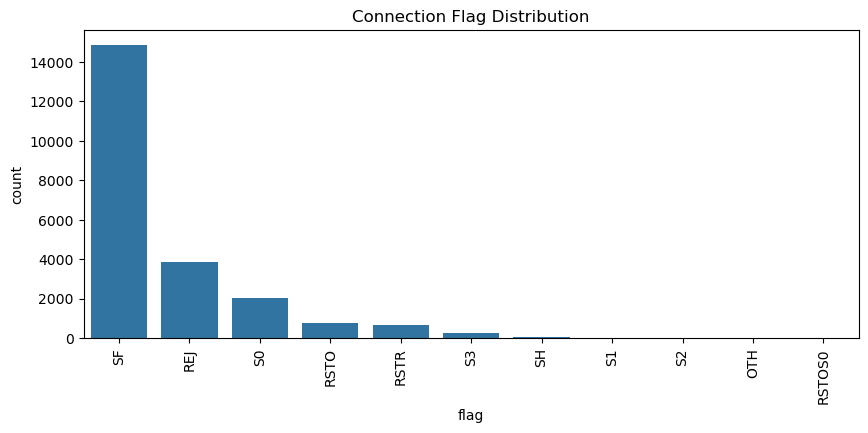

In [10]:
# Flag Distribution (Very Important Feature)

plt.figure(figsize=(10,4))
sns.countplot(x='flag', data=df, order=df['flag'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Connection Flag Distribution")
plt.show()

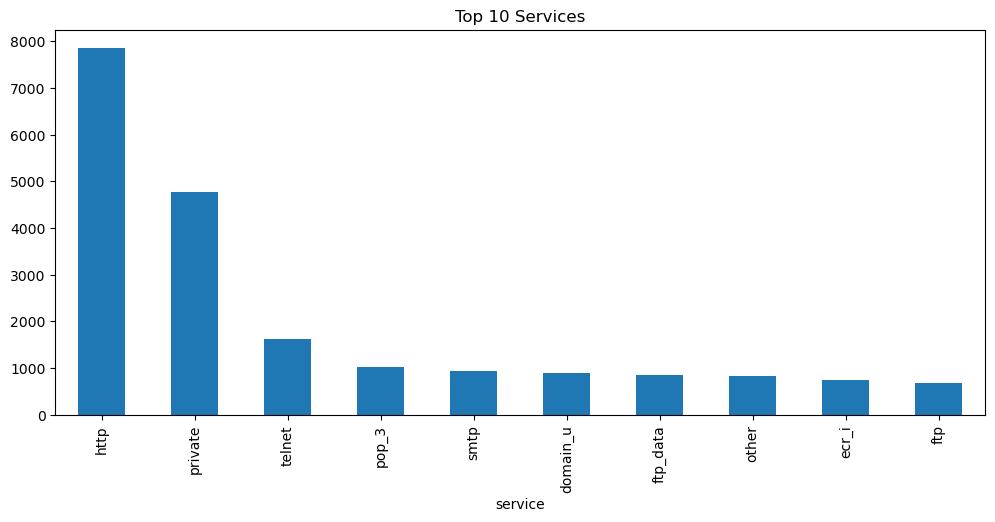

In [11]:
# Service Distribution (Top 10)

plt.figure(figsize=(12,5))
df['service'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Services")
plt.show()

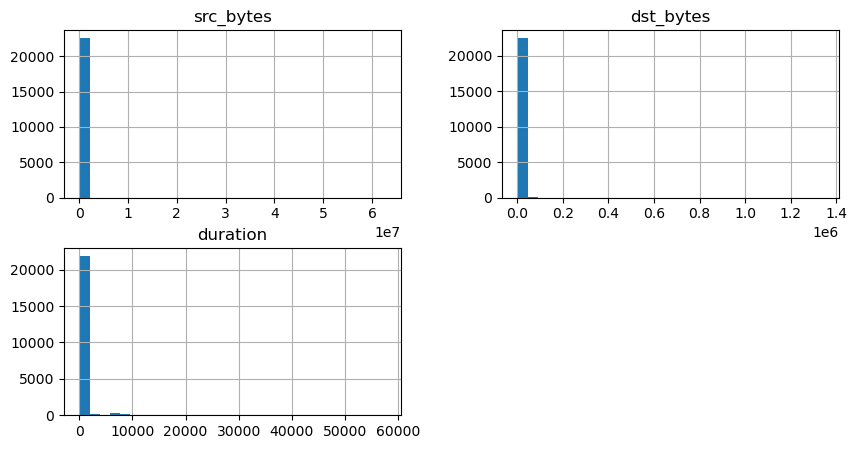

In [12]:
#  Feature Distribution (Check Scaling Need)
# SVM NEEDS scaling → this shows why

df[['src_bytes', 'dst_bytes', 'duration']].hist(figsize=(10,5), bins=30)
plt.show()

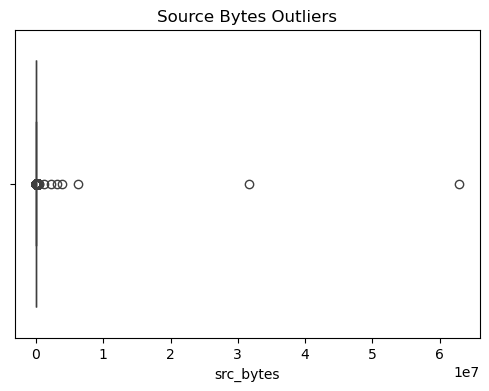

In [13]:
# Boxplot (Outliers Detection)

plt.figure(figsize=(6,4))
sns.boxplot(x=df['src_bytes'])
plt.title("Source Bytes Outliers")
plt.show()

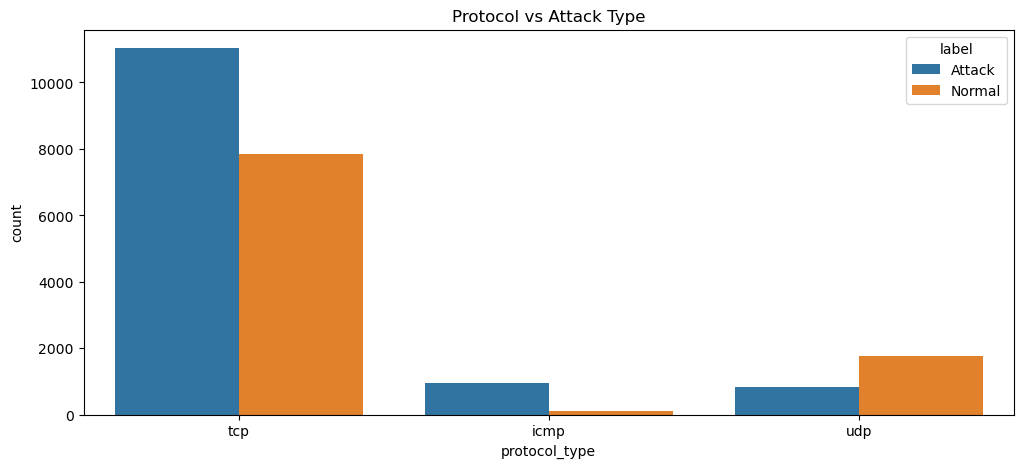

In [14]:
# Attack Type vs Protocol (Relationship Plot)

plt.figure(figsize=(12,5))
sns.countplot(x='protocol_type', hue='label', data=df)
plt.title("Protocol vs Attack Type")
plt.show()

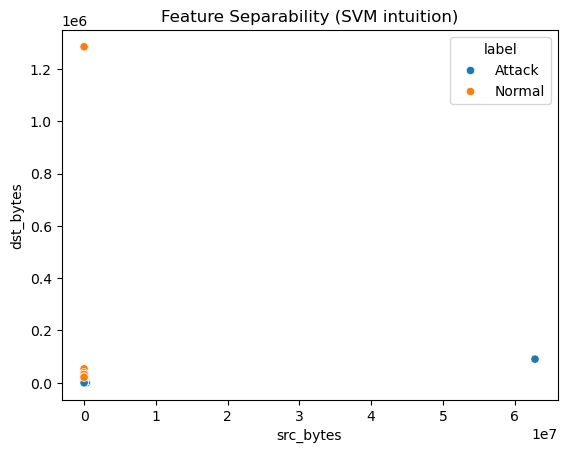

In [15]:
# Pairwise Feature Separation (SVM Insight)any
sns.scatterplot(
    x='src_bytes',
    y='dst_bytes',
    hue='label',
    data=df.sample(1000)
)
plt.title("Feature Separability (SVM intuition)")
plt.show()

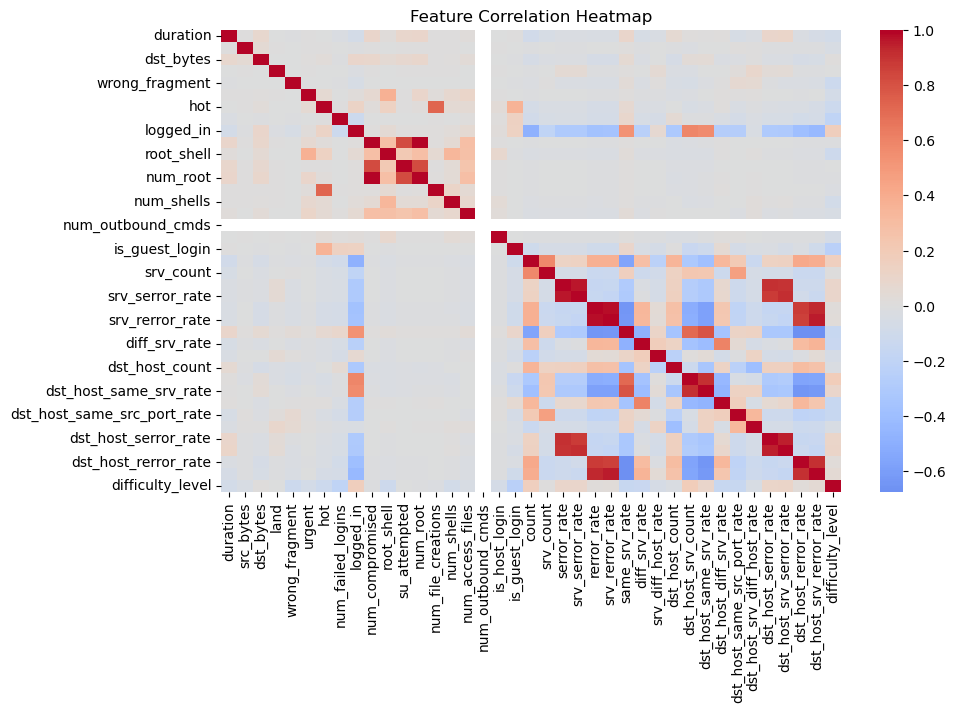

In [16]:
 # Correlation Heatmap (Numeric Features)

# Important for SVM feature selection
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
df.drop(columns=('difficulty_level'), inplace=True, errors='ignore')

In [18]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,label
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,Attack
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,Attack
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,Normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,Attack
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,Attack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,Normal
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,Normal
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,Attack
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,Normal


In [19]:
df['label'] = df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)


In [20]:
# . Feature Engineering (VERY IMPORTANT)
#  Log transform for skewed network traffic features

df['log_duration'] = np.log1p(df['duration'])
df['log_src_bytes'] = np.log1p(df['src_bytes'])
df['log_dst_bytes'] = np.log1p(df['dst_bytes'])

# Connection intensity features (VERY POWERFUL)

df['total_bytes'] = df['src_bytes'] + df['dst_bytes']
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)

# Error rate aggregation (security behavior signal)

df['error_rate'] = (
    df['serror_rate'] +
    df['rerror_rate'] +
    df['srv_serror_rate'] +
    df['srv_rerror_rate']
)

# Host-based risk score

df['host_risk'] = (
    df['dst_host_serror_rate'] +
    df['dst_host_rerror_rate'] +
    df['dst_host_srv_serror_rate'] +
    df['dst_host_srv_rerror_rate']
)


In [24]:
num_cols = [
'log_duration','log_src_bytes','log_dst_bytes',
'total_bytes','byte_ratio','wrong_fragment','urgent',
'count','srv_count','serror_rate','rerror_rate',
'same_srv_rate','diff_srv_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','error_rate','host_risk'
]

cat_cols = ['protocol_type', 'service', 'flag']

X = df[num_cols + ['protocol_type', 'service', 'flag']]
Y = df['label']

from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')


from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("Num", num_transformer, num_cols),
    ("Cat", cat_transformer, cat_cols)
])

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set shape : {X_train.shape}")
print(f"Testing  set shape : {X_test.shape}")

Training set shape : (18035, 24)
Testing  set shape : (4509, 24)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC())
])
pipe.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Num', ...), ('Cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
Y_pred = pipe.predict(X_test) 
print(Y_pred)

[0 1 0 ... 1 1 0]


In [30]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    
)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)


In [32]:
print("\n Support Vector Machine Results")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred))


 Support Vector Machine Results
Accuracy : 0.9709
Precision: 0.963
Recall   : 0.9872
F1 Score : 0.975

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1925
           1       0.96      0.99      0.97      2584

    accuracy                           0.97      4509
   macro avg       0.97      0.97      0.97      4509
weighted avg       0.97      0.97      0.97      4509


Confusion Matrix
[[1827   98]
 [  33 2551]]


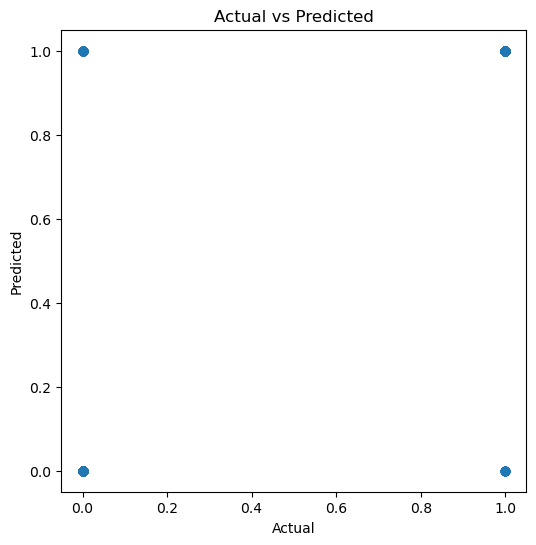

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Cross-Validation Scores: [0.9727 0.9745 0.9744 0.9771 0.9769]
Mean F1 Score: 0.9751035854871052
Std Deviation: 0.0016763217001712564


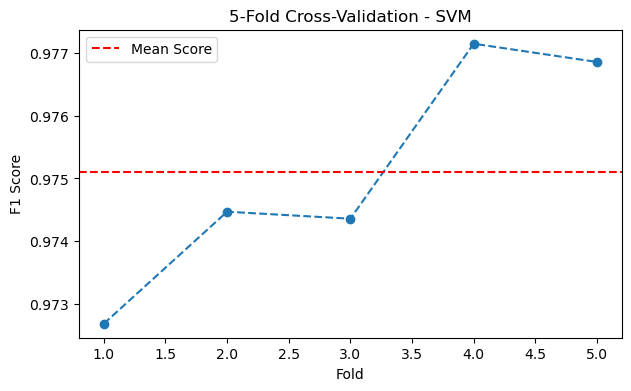

In [35]:
# Cross Validation 
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipe,
    X_train,
    Y_train,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print("Cross-Validation Scores:", np.round(cv_scores, 4))
print("Mean F1 Score:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())

# Visualise the fold scores
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='--')

plt.axhline(cv_scores.mean(), color='red', linestyle='--', label='Mean Score')

plt.title('5-Fold Cross-Validation - SVM')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [37]:
# ── GridSearchCV on SVM pipeline 
from sklearn.model_selection import GridSearchCV
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf']
}

svm_grid_search = GridSearchCV(
    estimator= Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC())
]),
    param_grid=svm_param_grid,
    cv=skf,          
    scoring='f1',
    n_jobs=-1,
     verbose=2
    
)

svm_grid_search.fit(X_train, Y_train)

print("Tuned Dt parameters :", svm_grid_search.best_params_)
print(f"Tuned CV accuracy    : {svm_grid_search.best_score_:.4f}")
Tuned_svm = svm_grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tuned Dt parameters : {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Tuned CV accuracy    : 0.9859


In [39]:
# Evaluate the tuned Dt on the held-out test set
Y_pred_tuned = Tuned_svm.predict(X_test)
print(Y_pred_tuned )

[0 1 0 ... 1 1 0]


In [40]:
accuracy = accuracy_score(Y_test, Y_pred_tuned)
precision = precision_score(Y_test, Y_pred_tuned)
recall = recall_score(Y_test, Y_pred_tuned)
f1 = f1_score(Y_test, Y_pred_tuned)

In [41]:
print("\n Tuned Support Vector Machine")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))


print("\nClassification Report")
print(classification_report(Y_test, Y_pred_tuned))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred_tuned))


 Tuned Support Vector Machine
Accuracy : 0.9854
Precision: 0.9914
Recall   : 0.983
F1 Score : 0.9872

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1925
           1       0.99      0.98      0.99      2584

    accuracy                           0.99      4509
   macro avg       0.98      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509


Confusion Matrix
[[1903   22]
 [  44 2540]]


In [43]:
# Collect all models and their predictions
models = {
    'SVM': (pipe, Y_pred),
    'Tuned SVM': (svm_grid_search, Y_pred_tuned)
    
}

results = []
for name, (model, preds) in models.items():

    try:
        proba = model.predict_proba(X_test)[:, 1]
        accuracy = accuracy_score(Y_test, Y_pred_tuned)
    except Exception:
        auc = float('nan')
    results.append({
        'Model'   : name,
        'f1': f1_score(Y_test, Y_pred),
        'accuracy' : accuracy_score(Y_test, Y_pred_tuned)
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.to_string(index=False))

    Model       f1  accuracy
      SVM 0.974967  0.985363
Tuned SVM 0.974967  0.985363


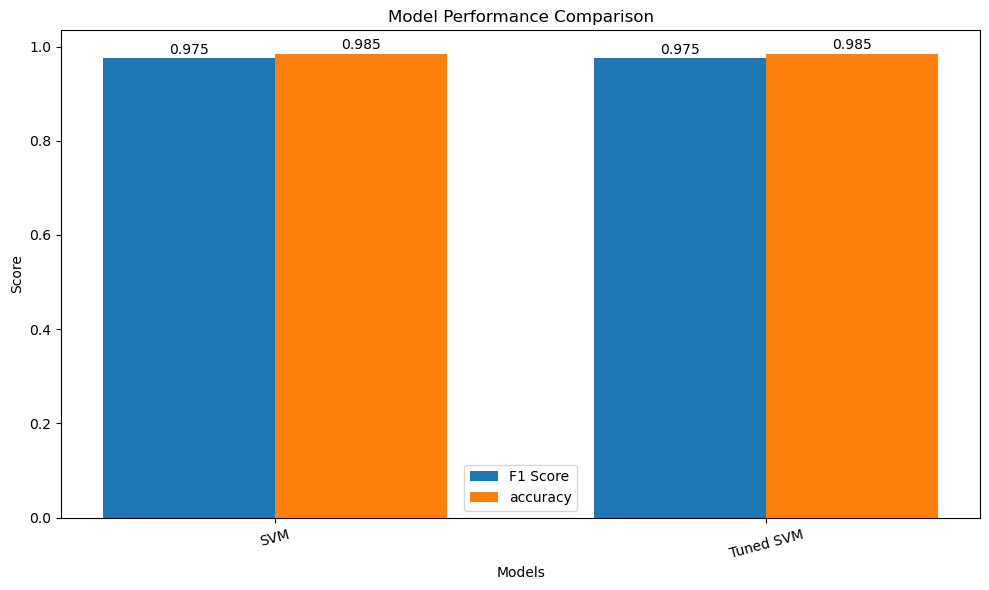

In [45]:
# Create figure
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(results_df))
width = 0.35

ax.bar(
    x - width/2,
    results_df['f1'],
    width,
    label='F1 Score'
)

ax.bar(
    x + width/2,
    results_df['accuracy'],
    width,
    label='accuracy'
)

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.legend()

# Add values on top
for i, v in enumerate(results_df['f1']):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center')

for i, v in enumerate(results_df['accuracy']):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

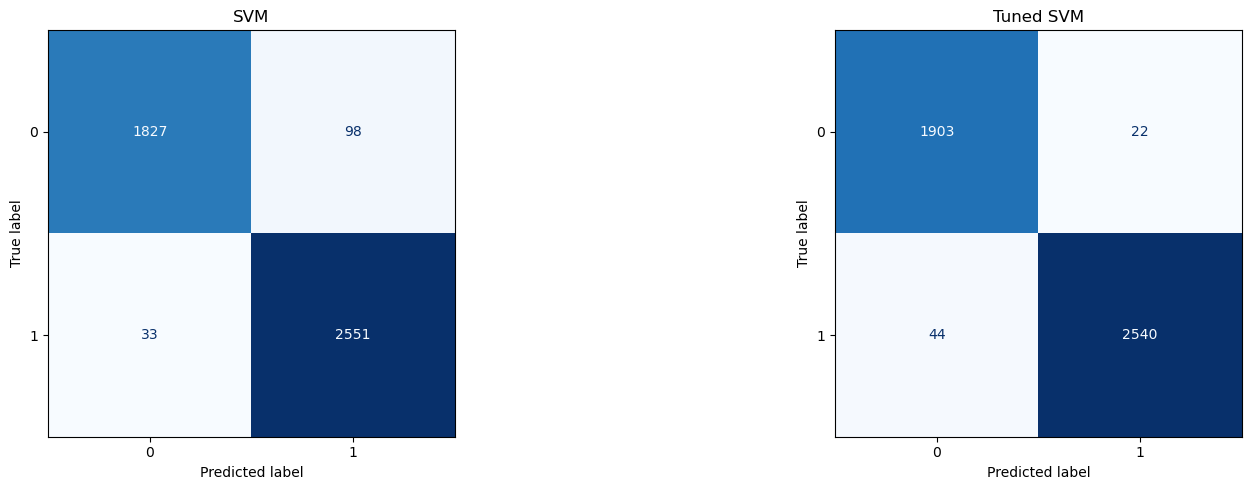

In [47]:
# Confusion matrices for all models

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18,5))

models = {
    "SVM": pipe,
    "Tuned SVM": svm_grid_search,
    
}

for ax, (name, model) in zip(axes, models.items()):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        Y_test,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

In [48]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj  = models[best_model_name][0]

In [49]:
import joblib
joblib.dump(best_model_obj, 'best_model.pkl')
print(f" Best model '{best_model_name}' saved to best_model.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")
print( "saved columns successfully")

 Best model 'SVM' saved to best_model.pkl
saved columns successfully
